# 로지스틱 회귀(Logistic Regression) 강의 자료

> 이름은 "회귀"지만 실제로는 **분류(Classification)** 의 대표 모델이다.
> 두 개의 실제 데이터로 이진분류 전체 흐름을 익힌다.

## 학습 목표
1. **분류 vs 회귀**의 차이를 알고, 로지스틱 회귀가 분류임을 이해한다.
2. **시그모이드(sigmoid)** 로 확률을 만들고 **임계값(0.5)** 으로 분류하는 원리를 안다.
3. 분류 전용 평가지표(**정확도·정밀도·재현율·F1·혼동행렬·ROC-AUC**)를 해석한다.
4. `stratify` 분할 등 **분류용 전처리 루틴**을 만든다.

## 사용 데이터
| 데이터 | 크기 | 타깃 | 특징 |
|--------|------|------|------|
| `heart.csv` | 918 × 12 | `HeartDisease` (0/1) | 원래 이진분류, 범주형 포함 |
| `Student_Performance.csv` | 10000 × 6 | (파생) 합격 여부 | 연속형 점수 → **이진 라벨 생성** |


## 1. 분류(Classification) vs 회귀(Regression) 복습

| 구분 | 예측 대상 | 예시 | 대표 모델 |
|------|-----------|------|-----------|
| 회귀 | **연속된 숫자** | 집값, 가격 | LinearRegression |
| **분류** | **범주(카테고리)** | 질병 유무(0/1), 합격/불합격 | **LogisticRegression** |

> 타깃이 "숫자의 크기"가 아니라 **"어느 그룹에 속하나"** 면 분류다.
> 이번 타깃들은 `HeartDisease`(있다/없다), `합격`(O/X) → 모두 **이진분류**.


## 2. 로지스틱 회귀(Logistic Regression)

### 한 줄 정의
**입력의 가중합을 시그모이드 함수에 통과시켜 "1일 확률(0~1)" 을 예측하는 분류 모델.**

### 직관적 설명
선형 회귀는 `w·x + b` 로 **숫자 그대로** 를 내놓는다. 하지만 분류는 확률(0~1)이 필요하다.
그래서 선형 회귀 결과를 **시그모이드(S자 곡선)** 에 넣어 0~1 사이로 눌러준다.

```
선형 결과 z = w·x + b   (범위 -∞ ~ +∞)
        ↓ 시그모이드
확률 p = 1 / (1 + e^(-z))   (범위 0 ~ 1)
        ↓ 임계값 0.5
p >= 0.5 → 1(양성),   p < 0.5 → 0(음성)
```

- `z` 가 크면 → `p` 는 1에 가까움 → "양성(1)" 예측
- `z` 가 작으면(음수) → `p` 는 0에 가까움 → "음성(0)" 예측

### 코드 예시 (개념 확인용)
```python
from sklearn.linear_model import LogisticRegression
import numpy as np

X = np.array([[1], [2], [3], [8], [9], [10]])
y = np.array([0, 0, 0, 1, 1, 1])            # 작은 값=0, 큰 값=1

model = LogisticRegression().fit(X, y)
print(model.predict([[2], [9]]))            # [0 1] : 클래스
print(model.predict_proba([[2], [9]])[:, 1])  # 1일 확률
```

### 📝 시험 출제 포인트
- `predict()` = **클래스(0/1)**, `predict_proba()[:, 1]` = **1일 확률**. 둘을 구분.
- `LogisticRegression(max_iter=1000)` — 수렴 경고 나면 `max_iter` 를 키운다.
- 분류 분할은 `train_test_split(..., stratify=y)` 로 클래스 비율 유지.

### ⚠️ 자주 하는 실수
- 분류 문제에 **LinearRegression 사용** → 확률/클래스가 아닌 엉뚱한 숫자.
- ROC-AUC에 `predict()`(0/1) 를 넣음 → **확률 `predict_proba`** 를 넣어야 한다.
- 불균형 데이터에서 **정확도만** 보고 좋다고 판단 → precision/recall도 확인.

### 관련 개념
- 다중분류: `LogisticRegression`(softmax) 또는 트리 계열.
- 임계값 조정: 0.5가 아닌 값으로 precision/recall 균형 조절.


## 3. 분류 평가지표 — 정확도만으론 부족하다

암 환자 100명 중 5명만 양성인데 모델이 "전부 음성"이라 찍으면 **정확도 95%** 다. 하지만 정작 환자를 한 명도 못 잡는다.
그래서 분류는 여러 지표를 함께 본다.

### 혼동행렬(Confusion Matrix)
| | 예측 0 | 예측 1 |
|--|:--:|:--:|
| **실제 0** | TN | FP |
| **실제 1** | FN | TP |

### 핵심 지표
| 지표 | 식 | 의미 | 언제 중요? |
|------|----|------|-----------|
| 정확도 Accuracy | (TP+TN)/전체 | 전체 중 맞춘 비율 | 클래스 균형일 때 |
| 정밀도 Precision | TP/(TP+FP) | 1이라 한 것 중 진짜 1 | 오탐(FP) 비쌀 때 (스팸) |
| 재현율 Recall | TP/(TP+FN) | 진짜 1 중 잡아낸 것 | 놓침(FN) 위험할 때 (암진단) |
| F1 | 정밀도·재현율 조화평균 | 둘의 균형 | 불균형 데이터 |
| ROC-AUC | ROC 곡선 아래 면적 | 임계값 무관 분류력(0.5=랜덤, 1=완벽) | 확률 품질 평가 |

### 📝 시험 출제 포인트
- `confusion_matrix`, `classification_report`, `roc_auc_score` 임포트는 `sklearn.metrics`.
- TP/FP/FN/TN 위치와 precision/recall 식 암기.


## 4. 전처리 루틴 (분류용)

회귀 때와 거의 같되 **두 가지가 다르다**:
1. 타깃이 **범주(0/1)** → 인코딩 필요 시 라벨 정수화.
2. 분할에서 **`stratify=y`** 로 train/test의 클래스 비율을 동일하게 유지.

표준 순서:
```
원본 → 불필요 컬럼 제거 → 결측치 처리 → 범주형 인코딩
     → train/test 분리(stratify) → 스케일링(train fit)
```

> 이번 데이터도 결측치는 0개지만, 전처리 루틴은 **습관처럼 항상** 갖춰 둔다.


In [1]:
# 공통 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

%matplotlib inline
pd.set_option('display.max_columns', 40)
print('ready')

ready


In [2]:
def preprocess_classification(df, target, drop_cols=None, high_card_threshold=50, verbose=True):
  """분류용 재사용 전처리 루틴 (결측치가 없어도 항상 동작).

  순서: 불필요 컬럼 제거 -> 결측치 처리(수치=중앙값, 범주=최빈값)
        -> 고카디널리티 범주형 제거 -> 원-핫 인코딩
  반환: (X 특성 DataFrame, y 타깃 Series)
  """
  data = df.copy()
  drop_cols = drop_cols or []
  data = data.drop(columns=[col for col in drop_cols if col in data.columns])

  y = data[target]
  X = data.drop(columns=[target])

  total_na = int(X.isnull().sum().sum())
  if verbose:
    print(f'[결측치] 총 {total_na}개 (없어도 처리 루틴은 실행)')

  num_cols = X.select_dtypes(include='number').columns
  cat_cols = X.select_dtypes(include='object').columns
  for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
  for col in cat_cols:
    fill = X[col].mode().iloc[0] if not X[col].mode().empty else 'NA'
    X[col] = X[col].fillna(fill)

  high_card = [col for col in cat_cols if X[col].nunique() > high_card_threshold]
  if high_card and verbose:
    print(f'[고카디널리티 제거] {high_card}')
  X = X.drop(columns=high_card)

  X = pd.get_dummies(X, drop_first=True)
  if verbose:
    print(f'[전처리 완료] X shape = {X.shape}')
  return X, y

## 5. 예제 1 — 심장병 진단 (heart.csv)

환자의 나이·혈압·콜레스테롤·흉통유형 등으로 **심장병 여부(`HeartDisease`)** 를 분류한다.
범주형(`Sex`, `ChestPainType` 등)이 있어 인코딩이 필요하다.


In [3]:
# 로드 & 탐색
df_h = pd.read_csv('pandas/data/heart.csv')
print('shape:', df_h.shape)
display(df_h.head())
print('\n[타깃 분포] (1=심장병)')
print(df_h['HeartDisease'].value_counts(normalize=True).round(3))

shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0



[타깃 분포] (1=심장병)
HeartDisease
1    0.553
0    0.447
Name: proportion, dtype: float64


In [4]:
# 전처리 루틴 적용
X_h, y_h = preprocess_classification(df_h, target='HeartDisease')
display(X_h.head(3))

[결측치] 총 0개 (없어도 처리 루틴은 실행)
[전처리 완료] X shape = (918, 15)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,True,True,False,False,False,True,False,False,True


In [5]:
# 분리: stratify 로 클래스 비율 유지
Xtr, Xte, ytr, yte = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42, stratify=y_h)
print('train 양성비:', round(ytr.mean(), 3), '| test 양성비:', round(yte.mean(), 3))

train 양성비: 0.553 | test 양성비: 0.554


In [6]:
# 스케일링 (train 으로만 fit)
sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

# 학습
clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr_s, ytr)
print('학습 완료')

학습 완료


In [7]:
# 예측: 클래스 vs 확률
pred = clf.predict(Xte_s)                 # 0/1
proba = clf.predict_proba(Xte_s)[:, 1]    # 1일 확률
print('예측 클래스 앞 5개:', pred[:5])
print('1일 확률 앞 5개  :', proba[:5].round(3))

예측 클래스 앞 5개: [1 0 1 1 0]
1일 확률 앞 5개  : [0.981 0.132 0.966 0.563 0.154]


In [8]:
# 핵심 지표
print(f'정확도 Accuracy  = {accuracy_score(yte, pred):.4f}')
print(f'정밀도 Precision = {precision_score(yte, pred):.4f}')
print(f'재현율 Recall    = {recall_score(yte, pred):.4f}')
print(f'F1 Score        = {f1_score(yte, pred):.4f}')
print(f'ROC-AUC         = {roc_auc_score(yte, proba):.4f}   (확률 사용!)')

정확도 Accuracy  = 0.8859


정밀도 Precision = 0.8716
재현율 Recall    = 0.9314
F1 Score        = 0.9005
ROC-AUC         = 0.9297   (확률 사용!)


In [9]:
# 상세 리포트
print(classification_report(yte, pred, target_names=['정상(0)', '심장병(1)']))

              precision    recall  f1-score   support

       정상(0)       0.91      0.83      0.87        82
      심장병(1)       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



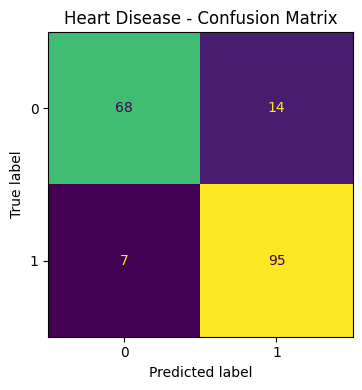

In [10]:
# 혼동행렬 시각화
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(yte, pred, display_labels=['0', '1'], ax=ax, colorbar=False)
ax.set_title('Heart Disease - Confusion Matrix')
plt.tight_layout(); plt.show()

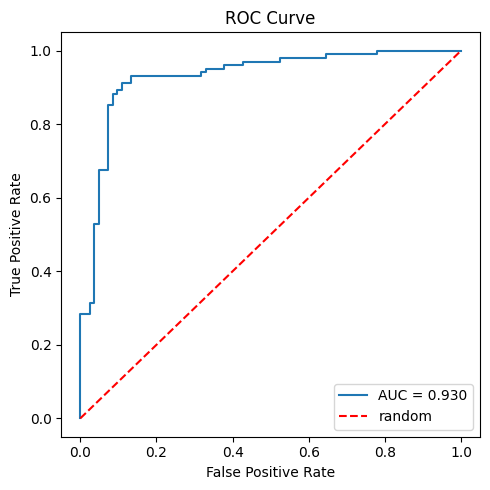

In [11]:
# ROC 곡선
fpr, tpr, _ = roc_curve(yte, proba)
auc = roc_auc_score(yte, proba)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], 'r--', label='random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()

In [12]:
# 계수 해석: exp(계수)=오즈비. 1보다 크면 심장병 확률을 높이는 특성
odds = pd.Series(np.exp(clf.coef_[0]), index=X_h.columns).sort_values(ascending=False)
print('심장병 위험을 높이는 특성 Top 5 (오즈비):')
print(odds.head(5).round(3).to_string())
print('\n위험을 낮추는 특성 Top 5:')
print(odds.tail(5).round(3).to_string())

심장병 위험을 높이는 특성 Top 5 (오즈비):
Sex_M               1.644
ST_Slope_Flat       1.629
ExerciseAngina_Y    1.556
FastingBS           1.544
Oldpeak             1.310

위험을 낮추는 특성 Top 5:
ChestPainType_TA     0.717
Cholesterol          0.608
ChestPainType_ATA    0.524
ST_Slope_Up          0.472
ChestPainType_NAP    0.462


## 6. 예제 2 — 학생 합격 예측 (Student_Performance.csv)

타깃 `Performance Index` 는 **연속형 점수**다. 분류를 하려면 **이진 라벨로 변환**해야 한다.
여기서는 **60점 이상을 "합격(1)"** 으로 정의한다 (연속형 → 이진 라벨 파생).


In [13]:
# 로드 & 이진 타깃 생성
df_s = pd.read_csv('pandas/data/Student_Performance.csv')
df_s['Pass'] = (df_s['Performance Index'] >= 60).astype(int)   # 60점 이상=합격
print('합격 비율:', round(df_s['Pass'].mean(), 3))
display(df_s.head(3))

합격 비율: 0.429


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index,Pass
0,7,99,Yes,9,1,91.0,1
1,4,82,No,4,2,65.0,1
2,8,51,Yes,7,2,45.0,0


In [14]:
# 전처리: 원본 연속 타깃은 제거(누설 방지), 범주형 'Extracurricular Activities' 인코딩
X_s, y_s = preprocess_classification(
    df_s, target='Pass', drop_cols=['Performance Index'])
display(X_s.head(3))

[결측치] 총 0개 (없어도 처리 루틴은 실행)
[전처리 완료] X shape = (10000, 5)


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_Yes
0,7,99,9,1,True
1,4,82,4,2,False
2,8,51,7,2,True


In [15]:
# 분리 -> 스케일 -> 학습 -> 평가 (예제1과 동일 흐름)
Xtr, Xte, ytr, yte = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42, stratify=y_s)

sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

clf_s = LogisticRegression(max_iter=1000).fit(Xtr_s, ytr)
pred_s = clf_s.predict(Xte_s)
proba_s = clf_s.predict_proba(Xte_s)[:, 1]

print(f'정확도   = {accuracy_score(yte, pred_s):.4f}')
print(f'정밀도   = {precision_score(yte, pred_s):.4f}')
print(f'재현율   = {recall_score(yte, pred_s):.4f}')
print(f'F1      = {f1_score(yte, pred_s):.4f}')
print(f'ROC-AUC = {roc_auc_score(yte, proba_s):.4f}')

정확도   = 0.9780
정밀도   = 0.9733


재현율   = 0.9755
F1      = 0.9744
ROC-AUC = 0.9978


              precision    recall  f1-score   support

      불합격(0)       0.98      0.98      0.98      1142
       합격(1)       0.97      0.98      0.97       858

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



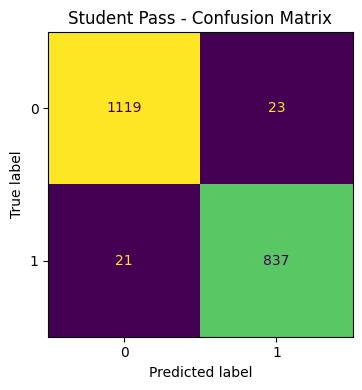

In [16]:
# 혼동행렬 + 리포트
print(classification_report(yte, pred_s, target_names=['불합격(0)', '합격(1)']))
fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(yte, pred_s, ax=ax, colorbar=False)
ax.set_title('Student Pass - Confusion Matrix')
plt.tight_layout(); plt.show()

In [17]:
# 합격에 영향 큰 특성 (오즈비)
odds_s = pd.Series(np.exp(clf_s.coef_[0]), index=X_s.columns).sort_values(ascending=False)
print('합격 확률을 높이는 특성 (오즈비):')
print(odds_s.round(3).to_string())

합격 확률을 높이는 특성 (오즈비):
Previous Scores                     139061.133
Hours Studied                          143.640
Sleep Hours                              1.765
Sample Question Papers Practiced         1.461
Extracurricular Activities_Yes           1.366


## 7. 예제 3 — 다중분류 (휴대폰 가격대 4분류)

`mobile_price_classification.csv` 의 `price_range` 는 **0,1,2,3 네 개 클래스**(저가~고가)다.
로지스틱 회귀로 **다중분류**를 해본다.

> 핵심: **코드는 이진분류와 똑같다.** 타깃에 클래스가 3개 이상이면 sklearn 이 자동으로
> **softmax(multinomial)** 다중분류를 수행한다. (이진의 sigmoid 를 N개 클래스로 일반화한 것)


In [18]:
# 로드 & 타깃 분포 (4클래스 균형)
df_m = pd.read_csv('pandas/data/mobile_price_classification.csv')
print('shape:', df_m.shape)
print('price_range 분포:')
print(df_m['price_range'].value_counts().sort_index().to_string())
display(df_m.head(3))

shape: (2000, 21)
price_range 분포:
price_range
0    500
1    500
2    500
3    500


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2


In [19]:
# 전처리 (전부 수치형 -> 인코딩 대상 없음)
X_m, y_m = preprocess_classification(df_m, target='price_range')
print('클래스 종류:', sorted(y_m.unique()))

[결측치] 총 0개 (없어도 처리 루틴은 실행)
[전처리 완료] X shape = (2000, 20)
클래스 종류: [0, 1, 2, 3]


In [20]:
# 분리 -> 스케일 -> 학습 (이진과 동일한 코드!)
Xtr, Xte, ytr, yte = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42, stratify=y_m)
sc = StandardScaler()
Xtr_s = sc.fit_transform(Xtr)
Xte_s = sc.transform(Xte)

clf_m = LogisticRegression(max_iter=2000).fit(Xtr_s, ytr)
print('클래스:', clf_m.classes_)
print('coef_ shape:', clf_m.coef_.shape, '= (클래스수, 특성수)  <- 클래스마다 가중치 한 벌')

클래스: [0 1 2 3]
coef_ shape: (4, 20) = (클래스수, 특성수)  <- 클래스마다 가중치 한 벌


In [21]:
# 확률 출력: shape (n, 4), 각 행의 합 = 1 (softmax)
proba_m = clf_m.predict_proba(Xte_s)
pred_m = clf_m.predict(Xte_s)
print('predict_proba shape:', proba_m.shape)
print('첫 샘플 클래스별 확률:', proba_m[0].round(3), '| 합 =', round(proba_m[0].sum(), 3))
print('첫 샘플 예측 클래스 :', pred_m[0])

predict_proba shape: (400, 4)
첫 샘플 클래스별 확률: [0. 0. 0. 1.] | 합 = 1.0
첫 샘플 예측 클래스 : 3


In [22]:
# 다중분류 평가: 평균 방식(average='macro')을 반드시 지정
print(f"정확도 Accuracy = {accuracy_score(yte, pred_m):.4f}")
print(f"F1 (macro)     = {f1_score(yte, pred_m, average='macro'):.4f}")
print(f"ROC-AUC (ovr)  = {roc_auc_score(yte, proba_m, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(yte, pred_m))

정확도 Accuracy = 0.9650
F1 (macro)     = 0.9650
ROC-AUC (ovr)  = 0.9987

              precision    recall  f1-score   support

           0       0.99      0.98      0.98       100
           1       0.96      0.96      0.96       100
           2       0.95      0.94      0.94       100
           3       0.96      0.98      0.97       100

    accuracy                           0.96       400
   macro avg       0.97      0.96      0.96       400
weighted avg       0.97      0.96      0.96       400



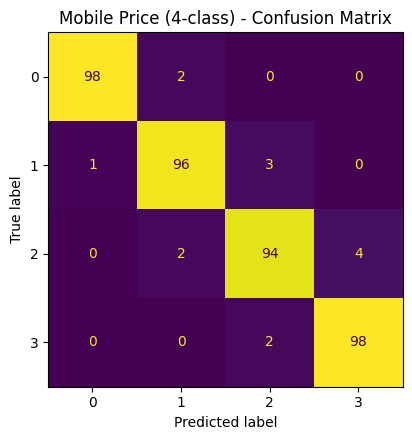

In [23]:
# 4x4 혼동행렬
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(yte, pred_m, ax=ax, colorbar=False)
ax.set_title('Mobile Price (4-class) - Confusion Matrix')
plt.tight_layout(); plt.show()

## 8. 정리 & 핵심 체크리스트

### 전체 흐름 (외워두기)
```
로드 → (필요시 이진 라벨 생성) → 전처리(인코딩) → 분리(stratify)
→ 스케일링(train fit) → LogisticRegression.fit
→ predict / predict_proba → 평가(Accuracy·Precision·Recall·F1·ROC-AUC)
```

### 회귀 vs 분류 한눈에
| 항목 | 선형 회귀 | 로지스틱 회귀 |
|------|-----------|---------------|
| 타깃 | 연속 숫자 | 범주(0/1) |
| 출력 | 값 | 확률 → 클래스 |
| 모델 | `LinearRegression` | `LogisticRegression` |
| 분할 | 그냥 split | `stratify=y` |
| 평가 | MAE/RMSE/R² | Accuracy/F1/ROC-AUC |

### 📝 시험 출제 포인트 (종합)
- `predict` vs `predict_proba` 구분 / ROC-AUC엔 확률 투입.
- `stratify=y`, `max_iter` 의 역할.
- 혼동행렬에서 precision·recall 계산.
- 연속형 타깃을 임계값으로 이진화하는 코드(`(col >= k).astype(int)`).
- **다중분류**: 코드는 이진과 동일, `predict_proba` shape=(n, 클래스수), 평가는 `average='macro'`.

### ⚠️ 자주 하는 실수 (종합)
- 불균형 데이터에서 정확도만 신뢰 → recall/F1 확인.
- 분류에 LinearRegression 사용.
- 이진 라벨을 만들 때 원본 연속 컬럼을 특성에서 안 빼서 **데이터 누설**.

### 다음 학습
- 임계값 튜닝(Precision-Recall 곡선), OvR vs Softmax 비교
- 트리 계열 분류기: `RandomForestClassifier`, `XGBoost`
